# 2. Descriptive Statistics: 
2.1. Calculate summary statistics for numerical fields. 2.2. Analyze categorical fields such as quality, stage, source, and product.

# 2 Описательная статистика: 
2.1. Рассчитайте сводную статистику для числовых полей. 2.2 Анализируйте категориальные поля, такие как качество, стадия, источник и продукт.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Loading the Deals_clean and Spend_clean tables to perform descriptive statistics. Conducting statistical analysis of numeric and categorical fields, focusing on those with direct business relevance.

Загрузка таблиц Deals_clean, Spend_clean  для проведения описательной статистики. Oсуществляем статистический анализ числовых и категориальных полей, фокусируя внимание на тех, которые имеют непосредственный бизнес-смысл.

In [2]:
df_deals = pd.read_pickle("../processed/Deals_clean.pkl") 
df_deals.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
0,5805028000056864695,Ben Hall,NaT,NaN,New Lead,NaN,03.07.23women,NaT,v16,women,...,2024-06-21 15:30:00,NaN,NaN,NaN,NaN,5805028000056849495,NaN,<NA>,Unknown,<NA>
1,5805028000056859489,Ulysses Adams,NaT,NaN,New Lead,NaN,Unknown,NaT,NaN,NaN,...,2024-06-21 15:23:00,6.0,NaN,0.0,2000.0,5805028000056834471,NaN,<NA>,Unknown,<NA>
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,engwien_AT,0 days 00:26:43,b1-at,21_06_2024,...,2024-06-21 00:00:00,NaN,NaN,NaN,NaN,5805028000056854421,NaN,<NA>,10-30 min,<NA>


In [3]:
df_deals.dtypes

Id                      string[python]
Deal Owner Name         string[python]
Closing Date            datetime64[ns]
Quality                         object
Stage                           object
Lost Reason                     object
Campaign                        object
SLA                    timedelta64[ns]
Content                         object
Term                            object
Source                          object
Payment Type                    object
Product                         object
Education Type                  object
Created Time            datetime64[ns]
Course duration                float64
Months of study                float64
Initial Amount Paid            float64
Offer Total Amount             float64
Contact Name            string[python]
City                            object
Level of Deutsch        string[python]
SLA_status                      object
level_norm                      object
dtype: object

Financial Summary: Key Metrics in Thousands of Euros. 
Финансовый обзор: ключевые метрики в тысячах евро.

In [4]:
paid_stats = pd.DataFrame({
    "sum": df_deals[["Initial Amount Paid", "Offer Total Amount"]].sum(),
    "min": df_deals[["Initial Amount Paid", "Offer Total Amount"]].min(),
    "max": df_deals[["Initial Amount Paid", "Offer Total Amount"]].max(),
    "mean": df_deals[["Initial Amount Paid", "Offer Total Amount"]].mean(),
    "median": df_deals[["Initial Amount Paid", "Offer Total Amount"]].median(),
    "mode": df_deals[["Initial Amount Paid", "Offer Total Amount"]].mode().iloc[0]
})

# Calculate range (max - min)
paid_stats["range"] = paid_stats["max"] - paid_stats["min"]
# Convert values to thousands of euros
paid_stats = paid_stats / 1000
# Round values (optional)
paid_stats = paid_stats.round(2)
# Rename columns
paid_stats.columns = ["sum (k€)", "min (k€)", "max (k€)", "mean (k€)", "median (k€)", "mode (k€)", "range (k€)"]
paid_stats

,sum (k€),min (k€),max (k€),mean (k€),median (k€),mode (k€),range (k€)
Initial Amount Paid,3872.60,0.0,11.0,0.93,1.0,1.0,11.0
Offer Total Amount,29918.22,0.0,11.5,7.15,11.0,11.0,11.5


Basic analysis of numeric fields: Course duration and Months of study.
Обзорный анализ числовых полей Course duration и Months of study.

In [5]:
numeric_fields = ["Course duration", "Months of study"]
print(df_deals[numeric_fields].describe())

print("\n Median ")
print(df_deals[numeric_fields].median())

print("\n Mode")
print(df_deals[numeric_fields].mode())

print("\nMissing Values (Count)")
missing_count = df_deals[numeric_fields].isna().sum()
print(missing_count)

print("\nMissing Values (%)")
missing_pct = (df_deals[numeric_fields].isna().sum() / len(df_deals) * 100).round(2)
print(missing_pct)

       Course duration  Months of study
count      3587.000000       840.000000
mean         10.198495         5.442857
std           1.834681         2.919920
min           6.000000         0.000000
25%          11.000000         3.000000
50%          11.000000         5.000000
75%          11.000000         8.000000
max          11.000000        11.000000

 Median 
Course duration    11.0
Months of study     5.0
dtype: float64

 Mode
   Course duration  Months of study
0             11.0              6.0

Missing Values (Count)
Course duration    18006
Months of study    20753
dtype: int64

Missing Values (%)
Course duration    83.39
Months of study    96.11
dtype: float64


Key Business Metrics Calculation.
Расчёт ключевых бизнес-метрик

In [6]:
# Total number of leads (all rows in Deals)
total_leads = len(df_deals)

# 1. Number of deals with Stage = "Payment Done"
paid_deals_stage = (df_deals["Stage"] == "Payment Done").sum()

# 2. Number of students: filter where Months of study > 0
students_mask = df_deals["Months of study"] > 0
students_count = students_mask.sum()

# 3. Number of students who completed the course: Months of study == Course duration > 0
completed_mask = (df_deals["Months of study"] == df_deals["Course duration"]) & (df_deals["Course duration"] > 0)
completed_count = completed_mask.sum()

# 4. Paid deals (Initial Amount Paid > 0)
paid_initial_mask = df_deals["Initial Amount Paid"] > 0
# Paid deals (Offer Total Amount > 0)
paid_total_mask = df_deals["Offer Total Amount"] > 0

paid_initial_count = paid_initial_mask.sum()
paid_total_count = paid_total_mask.sum()

Summary table of key business metrics

In [7]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total leads",
        "Deals with Stage = Payment Done",
        "Students (Months of study > 0)",
        "Completed students (Months of study == Course duration)",
        "Deals with Initial Amount Paid > 0",
        "Deals with Offer Total Amount > 0",
    ],
    "Value": [
        total_leads,
        paid_deals_stage,
        students_count,
        completed_count,
        paid_initial_count,
        paid_total_count,
    ]
})
business_summary

,Metric,Value
0,Total leads,21593
1,Deals with Stage = Payment Done,858
2,Students (Months of study > 0),839
3,Completed students (Months of study == Course ...,72
4,Deals with Initial Amount Paid > 0,3288
5,Deals with Offer Total Amount > 0,3338


Deals Count by Stage.
Колличество сделок по этапам.

In [8]:
stage_grouped_count = (
    df_deals.groupby("Stage")
    .size()
    .reset_index(name="Deals Count")
    .sort_values("Deals Count", ascending=False))
stage_grouped_count

,Stage,Deals Count
2,Lost,15743
0,Call Delayed,2248
10,Registered on Webinar,2072
7,Payment Done,858
12,Waiting For Payment,325
8,Qualificated,128
9,Registered on Offline Day,100
5,Need to Call - Sales,33
3,Need To Call,31
11,Test Sent,25


Deals Distribution by Stage
Распределение сделок по этапам

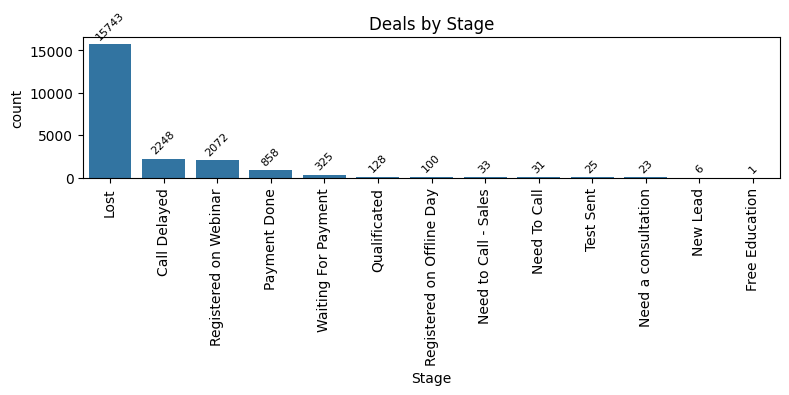

In [9]:
plt.figure(figsize=(8,4))
ax = sns.countplot(
    data=df_deals,
    x="Stage",
    order=df_deals["Stage"].value_counts().index
)
plt.xticks(rotation=90)
plt.title("Deals by Stage")
# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, rotation=45, padding=2)
plt.tight_layout()
plt.show()

Product statistics.
Статистика по продуктам.

In [10]:
print(f"\n=== {'Product'} ===")
print("Value counts:")
print(df_deals['Product'].value_counts(dropna=False))
print("\nRelative frequencies (%):")
print(df_deals['Product'].value_counts(normalize=True, dropna=False) * 100)


=== Product ===
Value counts:
Product
NaN                    18001
Digital Marketing       1990
UX/UI Design            1022
Web Developer            575
Find yourself in IT        4
Data Analytics             1
Name: count, dtype: int64

Relative frequencies (%):
Product
NaN                    83.364979
Digital Marketing       9.215950
UX/UI Design            4.733015
Web Developer           2.662900
Find yourself in IT     0.018525
Data Analytics          0.004631
Name: proportion, dtype: float64


Quality statistic. Статистика по полю Качество.

In [11]:
print(f"\n=== {'Quality'} ===")
print("Value counts:")
print(df_deals['Quality'].value_counts(dropna=False))
print("\nRelative frequencies (%):")
print(df_deals['Quality'].value_counts(normalize=True, dropna=False) * 100)


=== Quality ===
Value counts:
Quality
E - Non Qualified    7634
D - Non Target       6248
C - Low              3459
NaN                  2253
B - Medium           1564
A - High              432
F                       3
Name: count, dtype: int64

Relative frequencies (%):
Quality
E - Non Qualified    35.354050
D - Non Target       28.935303
C - Low              16.019080
NaN                  10.433937
B - Medium            7.243088
A - High              2.000648
F                     0.013893
Name: proportion, dtype: float64


Statistics for numeric fields in the Spend_clean table.
Статистика по числовым полям таблицы Spend_clean.

In [12]:
df_spend = pd.read_pickle(r"C:\Users\Dell 7530\Documents\ICH\Python for DA\Final project_DA _2026\processed\Spend_clean.pkl")
df_spend.head(3)

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,Unknown,0,0.00,0,NaN,NaN


In [13]:
print("Spend: basic info")
print(df_spend.shape)
print(df_spend.dtypes)

Spend: basic info
(19862, 8)
Date           datetime64[ns]
Source                 object
Campaign               object
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup                object
Ad                     object
dtype: object


In [14]:
numeric_cols = ["Impressions", "Spend", "Clicks"]

print("\n Numeric summary (Spend)")
print(df_spend[numeric_cols].describe())

print("\n Median (Spend)")
print(df_spend[numeric_cols].median())

print("\n Mode (Spend)")
print(df_spend[numeric_cols].mode()) 

print("\n Range (max - min) (Spend)")
print(df_spend[numeric_cols].max() - df_spend[numeric_cols].min())


 Numeric summary (Spend)
         Impressions         Spend        Clicks
count   19862.000000  19862.000000  19862.000000
mean     2571.695197      7.528117     25.095912
std     11691.227016     27.325150     87.032314
min         0.000000      0.000000      0.000000
25%         1.000000      0.000000      0.000000
50%        82.000000      0.740000      2.000000
75%       760.750000      6.160000     13.000000
max    431445.000000    774.000000   2415.000000

 Median (Spend)
Impressions    82.00
Spend           0.74
Clicks          2.00
dtype: float64

 Mode (Spend)
   Impressions  Spend  Clicks
0            0    0.0       0

 Range (max - min) (Spend)
Impressions    431445.0
Spend             774.0
Clicks           2415.0
dtype: float64
